$$
\begin{aligned}
& \text{\textbf{Sets \& Parameters:}} \\
& N = \{0, 1, \dots, n-1\} \quad \text{(Set of all nodes, 0 is Depot)} \\
& C = N \setminus \{0\} \quad \text{(Set of customers)} \\
& K = \{0, 1, \dots, m-1\} \quad \text{(Set of vehicles)} \\
& q_i \in \mathbb{Z}^+ \quad \text{(Demand of customer } i \text{)} \\
& Q \in \mathbb{Z}^+ \quad \text{(Vehicle capacity)} \\
& d_{ij} \ge 0 \quad \text{(Distance from node } i \text{ to node } j \text{)} \\ \\
& \text{\textbf{Decision Variables:}} \\
& z_{ik} \in \{0, 1\} \quad \text{(1 if customer } i \text{ is served by vehicle } k \text{)} \\
& x_{ijk} \in \{0, 1\} \quad \text{(1 if vehicle } k \text{ traverses arc } i \rightarrow j \text{)} \\
& y_k \in \{0, 1\} \quad \text{(1 if vehicle } k \text{ is used)} \\ \\
& \text{\textbf{Objective Function:}} \\
& \min \sum_{k \in K} \sum_{i \in N} \sum_{\substack{j \in N \\ j \neq i}} d_{ij} x_{ijk} + \epsilon \sum_{k \in K} y_k \quad (\epsilon = 0.001) \\ \\
& \text{\textbf{Constraints:}} \\
& \text{(1) Customer assignment:} \quad \sum_{k \in K} z_{ik} = 1 \quad \forall i \in C \\
& \text{(2) Vehicle activation:} \quad z_{ik} \le y_k \quad \forall i \in C, \; \forall k \in K \\
& \text{(3) Vehicle capacity:} \quad \sum_{i \in C} q_i z_{ik} \le Q \quad \forall k \in K \\
& \text{(4) Depot departure:} \quad \sum_{j \in C} x_{0jk} = y_k \quad \forall k \in K \\
& \text{(5) Depot return:} \quad \sum_{i \in C} x_{i0k} = y_k \quad \forall k \in K \\
& \text{(6) Self-loop for unassigned nodes:} \quad x_{iik} = 1 - z_{ik} \quad \forall i \in N, \; \forall k \in K \\
& \text{(7) Circuit validity:} \quad \text{Circuit}_k \left( \left\{ (i, j, x_{ijk}) \mid i, j \in N \right\} \right) \quad \forall k \in K \\
& \text{(8) Vehicle ordering:} \quad y_k \ge y_{k+1} \quad \forall k \in \{0, \dots, K-2\} \\
& \text{(9) Load ordering:} \quad L_k \ge L_{k+1} \quad \forall k \in \{0, \dots, K-2\} \\
& \qquad L_k = \sum_{i \in C} q_i z_{ik}
\end{aligned}
$$

In [1]:
# import random
# nodes = {
#     0: (0, 0), 1: (2, 5), 2: (8, 3), 3: (5, 9), 4: (1, 7),
#     5: (6, 4), 6: (9, 9), 7: (3, 1), 8: (7, 8), 9: (4, 4)
# }

# C = {i: nodes[i] for i in nodes.keys() if i!=0}

# N = len(nodes)
# K = 3
# Q = 15

# q = {i: random.randint(1,5) for i in C.keys()}

In [2]:
import random
import pandas as pd
from random import randint
random.seed(1)
df = pd.read_excel("data/points.xlsx")
nodes = {int(row["node"]): (row["x"], row["y"]) for i, row in df.head(15).iterrows()}


N = len(nodes)
K = 3
Q = 15

q = {i: random.randint(1,5) for i in nodes.keys() if i!=0}
sum(q.values())

40

In [3]:
import math
distance = {}
for i in range(N):
    for j in range(N):
        if i == j:
            distance[i,j] = 0
        else:
            xi,yi = nodes[i]
            xj,yj = nodes[j]
            dx, dy = xi-xj , yi-yj
            distance[i,j] = math.hypot(dx,dy)

In [4]:
from ortools.sat.python import cp_model

In [5]:
model = cp_model.CpModel()

In [6]:
x = {}
z = {}
y = {}
for i in range(N):
    for k in range(K):
        z[i,k] = model.NewBoolVar(f"z[{i},{k}]")


for k in range(K):
    y[k] = model.NewBoolVar(f"y[{k}]")
    
    arcs = []
    for i in range(N):
        for j in range(N):
            if i != j:
                x[i,j,k] = model.NewBoolVar(f"x[{i},{j},{k}]")
                arcs.append((i,j,x[i,j,k]))
            elif i == j:
                x[i,i,k] = z[i,k].Not()
                arcs.append((i,i,x[i,i,k]))
    model.AddCircuit(arcs)


In [7]:
#each customer served by exactly one vehicle
for i in range(N):
    if i != 0:
        model.AddExactlyOne([z[i,k] for k in range(K)])

for i in range(N):
    for k in range(K):
        if i!=0:
            model.Add(z[i,k] <= y[k])

In [8]:
"""can delete yi, it force model to use all vehicles"""
# Vehicle departure from depot
for k in range(K):
   # model.AddExactlyOne([x[0,j,k] for j in range(N) if j!=0])
   model.Add(sum(x[0,j,k] for j in range(N) if j!=0) == y[k]) 
    

# Vehicle return to depot
for k in range(K):
   # model.AddExactlyOne([x[i,0,k] for i in range(N) if i!=0]) 
   model.Add(sum(x[i,0,k] for i in range(N) if i!=0) == y[k]) 

In [9]:
#Vehicle capacity
for k in range(K):
    model.Add(sum(q[i]*z[i,k] for i in range(N) if i!=0) <= Q)

In [10]:
# load symmerty break
load = {}
for k in range(K):
    load[k] = sum(q[i] * z[i,k] for i in range(N) if i!=0)
for k in range(K-1):
    model.Add(load[k] >= load[k+1])
# vehicle used unused symmerty break
for k in range(K-1):
    model.Add(y[k] >= y[k+1])

In [11]:
obj_terms = []
for i in range(N):
    for j in range(N):
        for k in range(K):
            obj_terms.append(x[i,j,k]*distance[i,j])

model.Minimize(sum(obj_terms) + 1/1000*(sum(y[k] for k in range(K))))
# model.Minimize(sum(obj_terms))
    

In [12]:
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 20
status = solver.solve(model)

In [13]:
status

<CpSolverStatus.OPTIMAL: 4>

In [14]:
if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:

    print("Status:", solver.StatusName(status))
    print("Total distance:", solver.ObjectiveValue())

    for k in range(K):
        print(f"\nVehicle {k}")

        route = []
        load = 0

        # Find the route starting from depot
        current = 0
        route.append(current)

        while True:
            next_node = None

            for j in range(N):
                if j != current and solver.Value(x[current, j, k]):
                    next_node = j
                    break

            if next_node is None or next_node == 0:
                route.append(0)
                break

            route.append(next_node)

            if next_node != 0:
                load += q[next_node]

            current = next_node

        print("Route:", route)
        print("Load:", load)

else:
    print("No solution found.")

Status: OPTIMAL
Total distance: 550.9358307756496

Vehicle 0
Route: [0, 10, 12, 11, 9, 7, 0]
Load: 15

Vehicle 1
Route: [0, 1, 13, 3, 5, 8, 6, 0]
Load: 13

Vehicle 2
Route: [0, 14, 4, 2, 0]
Load: 12


In [15]:
# print("Objective:", solver.ObjectiveValue())
# print("Best Bound:", solver.BestObjectiveBound())
# print("Wall Time:", solver.WallTime())
# print("Branches:", solver.NumBranches())
# print("Conflicts:", solver.NumConflicts())
# print("Gap": (solver.ObjectiveValue() -  solver.BestObjectiveBound()) / solver.objective_value * 100)

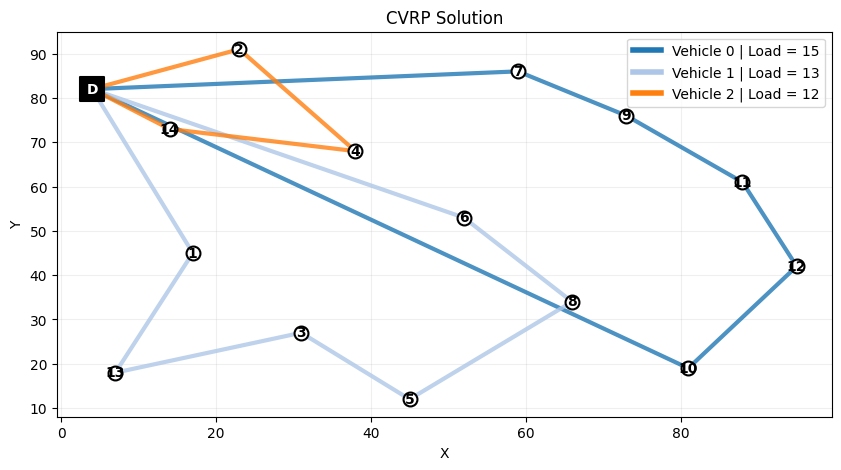

In [20]:
# Directly copy-pasted this part from AI

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab20.colors

# Nodes
for i, pos in nodes.items():
    ax.scatter(*pos, s=300 if i == 0 else 100,
               marker="s" if i == 0 else "o",
               c="black" if i == 0 else "white",
               edgecolors="black" if i != 0 else None,
               linewidths=1.5, zorder=10)
    ax.text(*pos, "D" if i == 0 else i,
            ha="center", va="center",
            color="white" if i == 0 else "black",
            fontweight="bold", zorder=11)

# Routes
for k in range(K):
    if not solver.Value(y[k]):
        continue

    color = colors[k % 20]

    for i in range(N):
        for j in range(N):
            if i != j and solver.Value(x[i, j, k]):
                ax.plot(*zip(nodes[i], nodes[j]),
                        color=color, linewidth=3, alpha=.8)

    load = sum(q[i] * solver.Value(z[i, k]) for i in range(1, N))
    ax.plot([], [], color=color, lw=4,
            label=f"Vehicle {k} | Load = {load}")

ax.set(title="CVRP Solution", xlabel="X", ylabel="Y")
ax.grid(alpha=.2)
ax.legend()
plt.show()